In [1]:
import numpy as np
import os
import skimage.io
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

fontprops = fm.FontProperties(size=14)
import json
import skimage

In [2]:
toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')
processing_dict = json.load(open(processing_dict_path,'r'))

In [3]:
series = 'B'
sample = '6'
stage = 'dry'
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)

In [4]:
path = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')
segpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_BPM_segmented.tif')

In [5]:
im = skimage.io.imread(path)
imseg = skimage.io.imread(segpath)

In [6]:
def extract_membrane_layer_thicknesses(imseg):
    BPM = imseg == 0

    BPMth = BPM.sum(axis=2)

    th = {'BPM': BPMth.mean(), 'BPM_std': BPMth.std()}
    return th

In [7]:
stages = ['dry', 'wet_1', 'wet_240C']

In [8]:
th = {}
for stage in stages:
    segpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_BPM_segmented.tif')
    imseg = skimage.io.imread(segpath)
    thst = extract_membrane_layer_thicknesses(imseg)
    th[stage] = thst

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/B_series/B_6/B_6_wet_1_BPM_segmented.tif'

In [9]:
th

{'dry': {'BPM': 22.63147142857143, 'BPM_std': 5.067800191399903}}

In [10]:
22.6*3

67.80000000000001

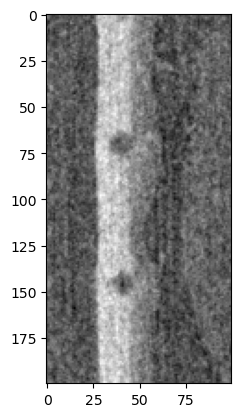

In [98]:
plt.imshow(im[600:800,550,:], 'gray')

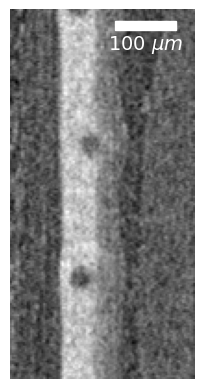

In [155]:
fig, ax = plt.subplots()
# ax[0].imshow(im[600:800,460,:], 'gray')
# ax[0].axis('off')
# scalebar = AnchoredSizeBar(ax[0].transData,
#                            100/3, '100 $\mu m$', 'upper right', 
#                            pad=0.5,
#                            color='white',
#                            frameon=False,
#                            size_vertical=5,
#                            fontproperties=fontprops)
# ax[0].add_artist(scalebar)

ax.imshow(im[600:800,560,:], 'gray')
# ax.imshow(imseg[600:800,560,:], cmap = cm.Set1, alpha=0.5, vmin=0, vmax=2,interpolation='none')
ax.axis('off')
scalebar = AnchoredSizeBar(ax.transData,
                           100/3, '100 $\mu m$', 'upper right', 
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=5,
                           fontproperties=fontprops)
ax.add_artist(scalebar)
plotpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'BPM.png')
# plt.savefig(plotpath, bbox_inches='tight')

In [128]:
segpath

'/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem/Z_series/Z_2/Z_2_wet_2_BPM_segmented.tif'

In [76]:
BPM = imseg == 0
BPMth = BPM.sum(axis=2)

In [26]:
BPMth.max()*3

180

(array([3.90700e+03, 2.50000e+01, 7.80000e+01, 1.82000e+02, 2.41000e+02,
        3.15000e+02, 2.53000e+02, 2.57000e+02, 2.01000e+02, 1.37000e+02,
        1.89000e+02, 2.59000e+02, 3.06000e+02, 5.15000e+02, 8.70000e+02,
        1.58000e+03, 2.62900e+03, 4.26500e+03, 6.59900e+03, 9.81100e+03,
        1.36950e+04, 1.74560e+04, 2.15950e+04, 2.55600e+04, 2.95850e+04,
        3.26910e+04, 3.65720e+04, 4.32310e+04, 5.23000e+04, 6.96360e+04,
        9.04630e+04, 1.01579e+05, 9.96960e+04, 8.17670e+04, 5.78940e+04,
        3.66680e+04, 2.02310e+04, 1.04930e+04, 5.65700e+03, 3.33400e+03,
        2.07900e+03, 1.26500e+03, 8.63000e+02, 5.91000e+02, 4.69000e+02,
        3.31000e+02, 2.62000e+02, 1.85000e+02, 2.28000e+02]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49.]

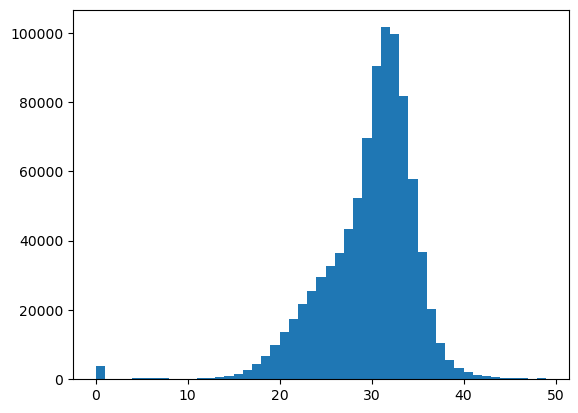

In [14]:
plt.hist(BPMth.flatten(), bins = np.arange(0,50,1))

In [46]:
dry_hist = np.histogram(BPMth.flatten(), bins = np.arange(0,50,1), density=True)

In [47]:
import tikzplotlib

In [53]:
x = np.arange(1,50,1)*3

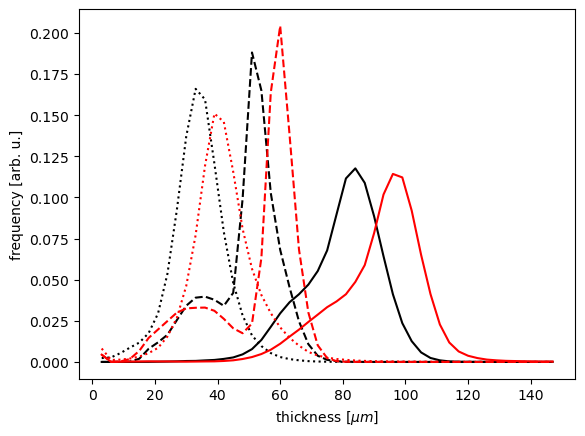

In [59]:
plt.plot(x, dry_hist[0], 'k', label='dry BPM')

plt.plot(x, wet_hist[0], 'r', label='wet BPM')

# plt.legend()
plt.xlabel('thickness [$\mu m$]')
plt.ylabel('frequency [arb. u.]')
plotpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'BPM_with_CL_th_dist.tex')
# tikzplotlib.save(plotpath)

In [63]:
for key in th.keys():
    for key2 in th[key].keys():
        print(key, key2, th[key][key2]*3)

dry AEM 45.87791208791209
dry AEM_std 10.991507512569191
dry CEM 31.001897802197803
dry CEM_std 8.671362347969055
dry BPM 76.8798098901099
dry BPM_std 12.134898698604642
wet_2 AEM 48.958073549257755
wet_2 AEM_std 14.300546404346811
wet_2 CEM 38.9375641025641
wet_2 CEM_std 11.127877808088467
wet_2 BPM 87.89563765182186
wet_2 BPM_std 15.263340524468084
wet_3 AEM 47.352277460530736
wet_3 AEM_std 13.511437398142705
wet_3 CEM 40.812925764192144
wet_3 CEM_std 10.50653706031933
wet_3 BPM 88.16520322472289
wet_3 BPM_std 13.166375489649653


In [77]:
V_wet = BPMth.sum()
V_wet_AEM = AEMth.sum()
V_wet_CEM = CEMth.sum()

In [71]:
V_dry

23320209

In [78]:
V_wet

26052267

In [97]:
(V_wet_CEM-V_dry_CEM)/V_dry_CEM*100

22.726559774238563

In [83]:
px = 3E-3

In [96]:
(th['wet_2']['CEM']-th['dry']['CEM'])/th['dry']['CEM']*100

25.597356494103785

In [98]:
V

NameError: name 'V' is not defined

In [99]:
V = {}
V['dry'] = {'BPM': V_dry}
V['wet_1'] = {'BPM': V_wet}
V['wet_2_40C'] = {'BPM': V_wet2}

In [100]:
V

{'dry': {'BPM': 23320209, 'AEM': 13916300, 'CEM': 9403909},
 'wet_2': {'BPM': 26052267, 'AEM': 14511173, 'CEM': 11541094}}

In [101]:
th

{'dry': {'AEM': 15.292637362637363,
  'AEM_std': 3.6638358375230635,
  'CEM': 10.333965934065935,
  'CEM_std': 2.8904541159896846,
  'BPM': 25.626603296703298,
  'BPM_std': 4.044966232868214},
 'wet_2': {'AEM': 16.319357849752585,
  'AEM_std': 4.766848801448937,
  'CEM': 12.979188034188034,
  'CEM_std': 3.7092926026961557,
  'BPM': 29.29854588394062,
  'BPM_std': 5.0877801748226945},
 'wet_3': {'AEM': 15.784092486843578,
  'AEM_std': 4.5038124660475685,
  'CEM': 13.604308588064047,
  'CEM_std': 3.502179020106443,
  'BPM': 29.388401074907627,
  'BPM_std': 4.388791829883218}}